# VayuVision — Exploratory Data Analysis

## Objective

This notebook explores AQI patterns for Delhi, Mumbai, and Bengaluru.

The analysis examines AQI distributions, pollution trends, monthly patterns, missing values, pollutant relationships, and differences between weekdays and weekends.

All charts use the raw dataset. Rows with missing AQI are excluded only where AQI is required for a chart.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("data/raw/city_day.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/city_day.csv")

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

selected_cities = ["Delhi", "Mumbai", "Bengaluru"]

eda_df = df[df["City"].isin(selected_cities)].copy()
eda_df = eda_df.dropna(subset=["AQI"])

print("Rows used for AQI analysis:", len(eda_df))
print("Cities included:", eda_df["City"].unique())

Matplotlib is building the font cache; this may take a moment.


Rows used for AQI analysis: 4684
Cities included: <ArrowStringArray>
['Bengaluru', 'Delhi', 'Mumbai']
Length: 3, dtype: str


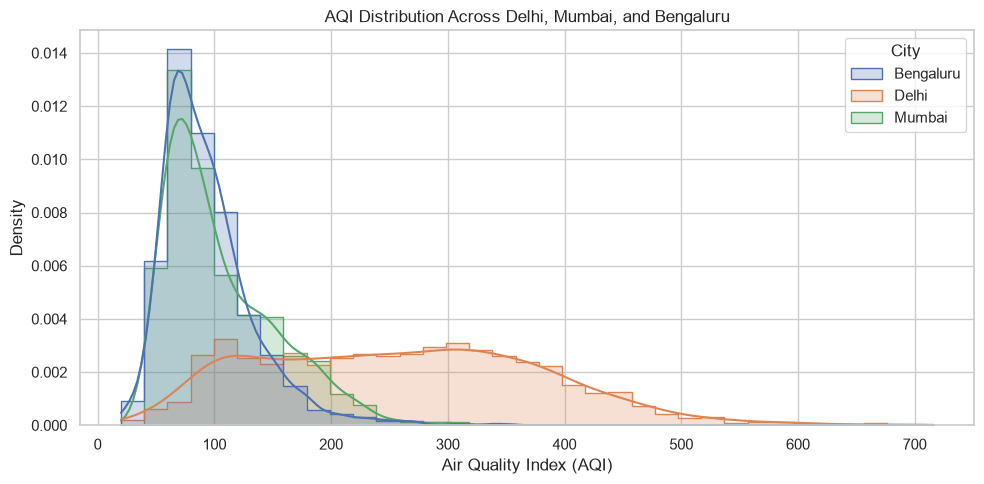

In [2]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="AQI",
    hue="City",
    bins=35,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("AQI Distribution Across Delhi, Mumbai, and Bengaluru")
plt.xlabel("Air Quality Index (AQI)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## Insight

Delhi’s AQI distribution is shifted much further towards higher values than Mumbai and Bengaluru, indicating generally poorer air quality.

Delhi also has a wider distribution and a long right tail, showing that it experiences greater AQI variation and occasional extremely polluted days.

Mumbai and Bengaluru are concentrated at lower AQI values, although Mumbai shows some higher-AQI observations.

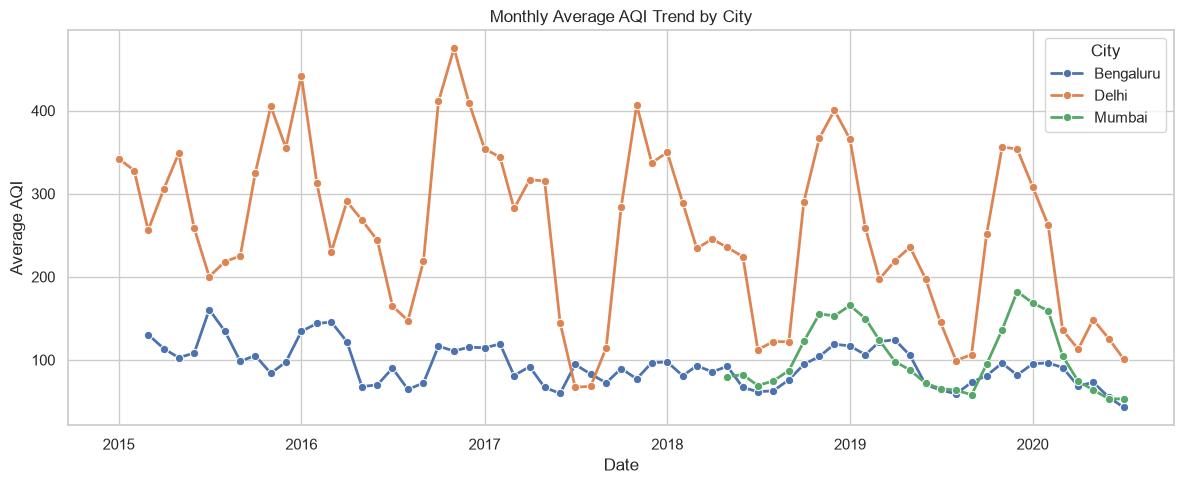

In [3]:
monthly_aqi = (
    eda_df
    .groupby(["City", pd.Grouper(key="Date", freq="MS")])["AQI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_aqi,
    x="Date",
    y="AQI",
    hue="City",
    marker="o",
    linewidth=2
)

plt.title("Monthly Average AQI Trend by City")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.legend(title="City")
plt.tight_layout()
plt.show()

## Insight

Delhi has consistently higher monthly average AQI and greater variation than Bengaluru and Mumbai.

Bengaluru remains comparatively stable at lower AQI levels. Mumbai also has lower AQI than Delhi, although its available data covers a shorter portion of the overall period.

The trend chart also highlights why missing values must be handled carefully before modelling, because missing AQI records can create gaps in time-series analysis.

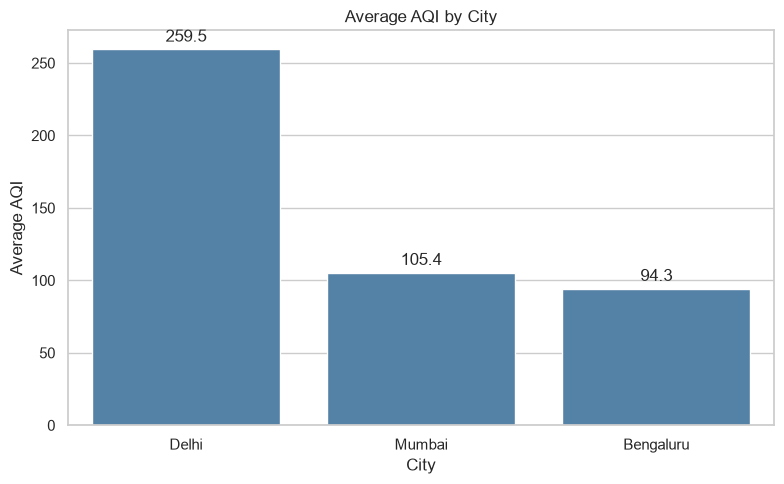

In [5]:
city_average_aqi = (
    eda_df
    .groupby("City", as_index=False)["AQI"]
    .mean()
    .sort_values("AQI", ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=city_average_aqi,
    x="City",
    y="AQI",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

## Insight

Delhi has the highest average AQI among the three selected cities, at 259.5.

Mumbai has an average AQI of 105.4, while Bengaluru has the lowest average AQI at 94.3.

This indicates that Delhi has substantially poorer air quality on average in the available data. However, comparisons should consider that cities may have different date coverage and missing-AQI patterns.

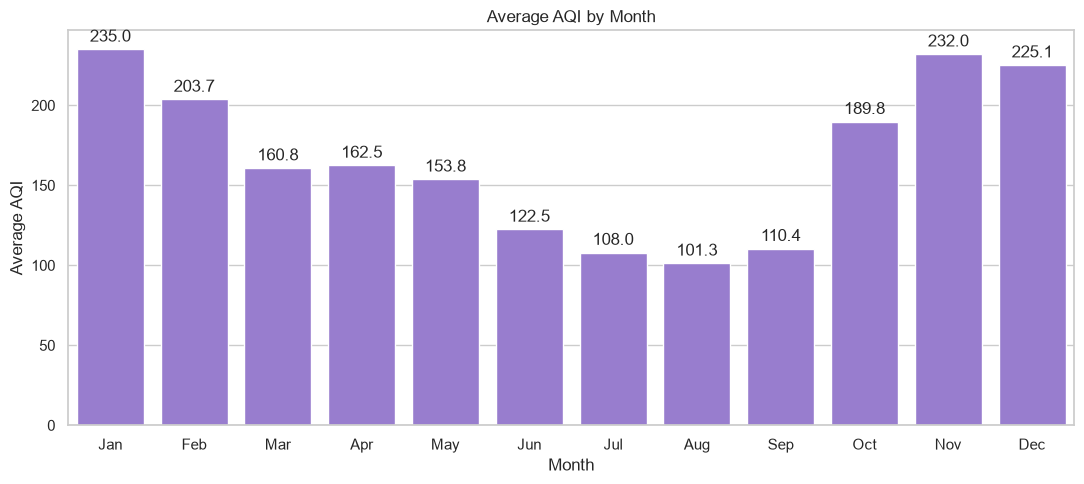

In [6]:
monthly_average_aqi = (
    eda_df
    .assign(Month=eda_df["Date"].dt.month)
    .groupby("Month", as_index=False)["AQI"]
    .mean()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_average_aqi["Month name"] = (
    monthly_average_aqi["Month"]
    .apply(lambda month: month_names[month - 1])
)

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=monthly_average_aqi,
    x="Month name",
    y="AQI",
    color="mediumpurple"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

## Insight

Average AQI is highest in January, followed by November and December. The lowest average AQI occurs in August.

This indicates a seasonal pollution pattern: air quality is generally poorer in winter and better during the monsoon months. This may be related to lower atmospheric dispersion in winter and rainfall washing particulate matter from the air during monsoon periods.

Because this chart combines all three cities, it represents the overall pattern in the available selected-city data rather than a separate seasonal pattern for each city.

## Missing-Value Analysis

This heatmap shows the percentage of missing values for each numerical air-quality column in Delhi, Mumbai, and Bengaluru.

Darker colours represent a higher percentage of missing values.

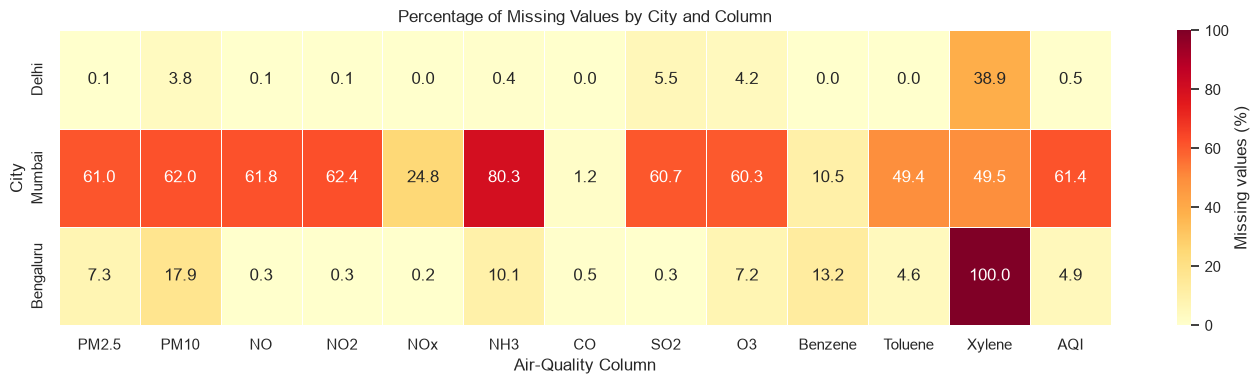

In [7]:
selected_raw_data = df[df["City"].isin(selected_cities)].copy()

numeric_columns = selected_raw_data.select_dtypes(include="number").columns

missing_by_city = (
    selected_raw_data
    .groupby("City")[numeric_columns]
    .agg(lambda column: column.isna().mean() * 100)
    .reindex(selected_cities)
)

plt.figure(figsize=(14, 4))

sns.heatmap(
    missing_by_city,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Missing values (%)"}
)

plt.title("Percentage of Missing Values by City and Column")
plt.xlabel("Air-Quality Column")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## Insight

Missingness differs substantially across cities.

Delhi has low missing-value percentages for most air-quality columns. Mumbai has high missingness across several pollutant columns and AQI. Bengaluru has 100% missing values for Xylene.

AQI values will not be imputed because AQI is the prediction target. Rows without AQI will be removed during data cleaning. Pollutant values will be imputed using city-level medians where a valid city median exists; columns with no available values for a city will not be used as model features.

## Correlation Analysis

This heatmap shows the linear relationship between pollutant measurements and AQI.

Correlation values range from -1 to 1:

- A value close to 1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates little linear relationship.

Correlation shows association, not causation.

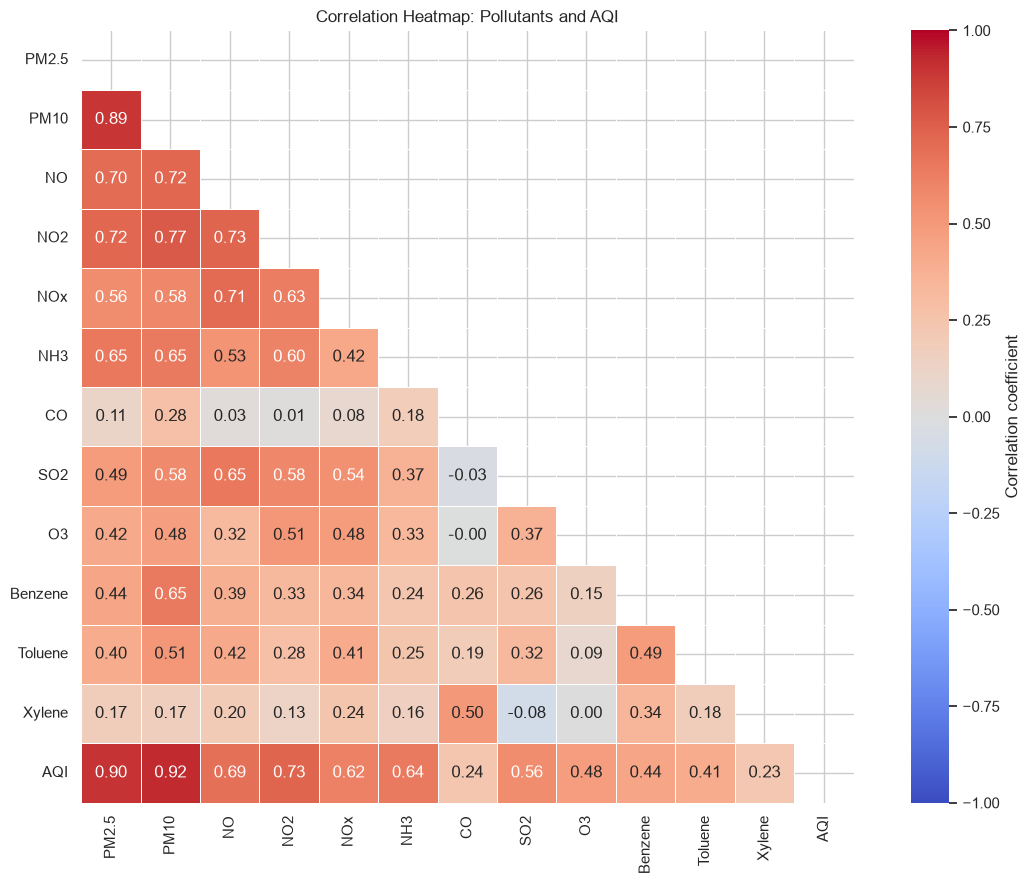

In [ ]:
correlation_columns = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3",
    "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"
]


correlation_matrix = eda_df[correlation_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation Heatmap: Pollutants and AQI")
plt.tight_layout()
plt.show()

## Insight

PM10 has the strongest positive correlation with AQI (0.92), followed closely by PM2.5 (0.90).

NO2 also has a notable positive correlation with AQI (0.73). This suggests that particulate matter and nitrogen dioxide are useful candidate features for AQI forecasting.

Correlation does not prove that one variable causes another. In addition, correlations are calculated from available paired values, so high missingness in some pollutant columns should be considered during feature selection and data cleaning.

## AQI Spread and Outliers by City

This boxplot compares AQI distributions across Delhi, Mumbai, and Bengaluru.

It shows the median AQI, the middle 50% of values, the overall spread, and potential outliers for each city.

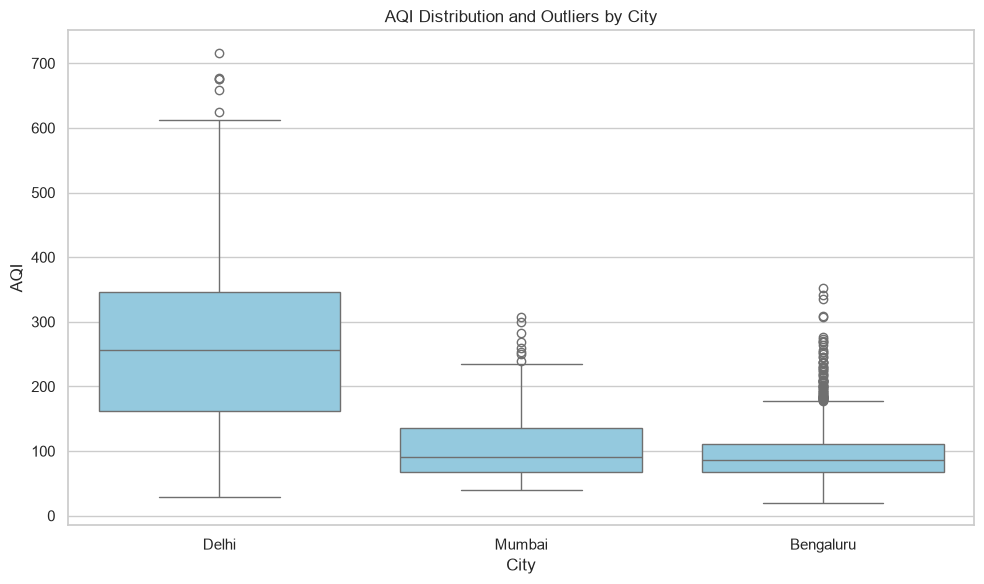

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df,
    x="City",
    y="AQI",
    order=selected_cities,
    color="skyblue",
    showfliers=True
)

plt.title("AQI Distribution and Outliers by City")
plt.xlabel("City")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

## Insight

Delhi has the highest median AQI and the widest interquartile range, showing both poorer average air quality and greater day-to-day variation.

Mumbai and Bengaluru have lower and more compact AQI distributions. All three cities contain high-AQI outliers, but Delhi has the most extreme values.

These outliers may represent genuine severe-pollution days, so they should be flagged for review rather than automatically deleted.

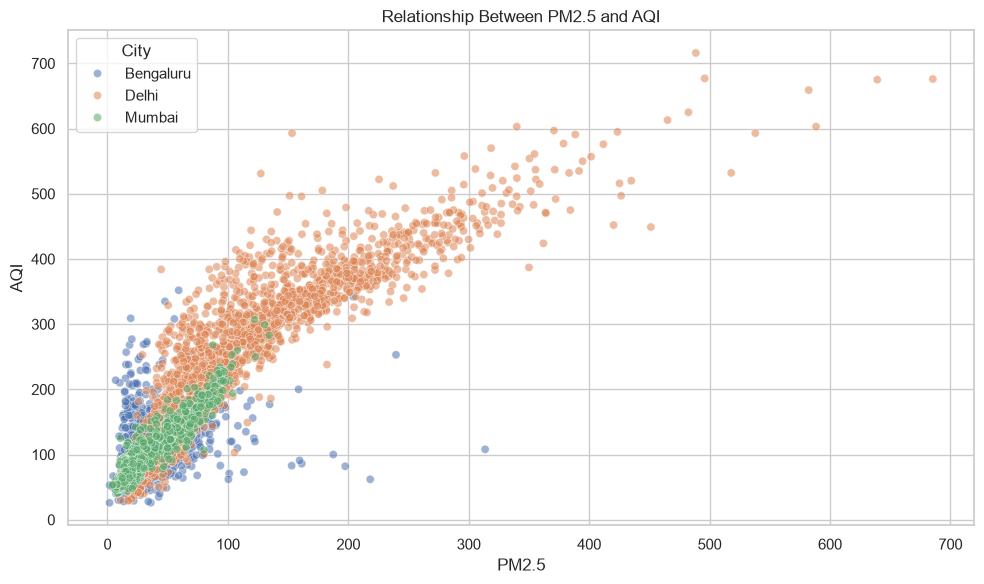

In [13]:
pm25_aqi_data = eda_df.dropna(subset=["PM2.5", "AQI"])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pm25_aqi_data,
    x="PM2.5",
    y="AQI",
    hue="City",
    alpha=0.55,
    s=35
)

plt.title("Relationship Between PM2.5 and AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.legend(title="City")
plt.tight_layout()
plt.show()

## Insight

The scatter plot shows a strong positive relationship between PM2.5 and AQI: as PM2.5 increases, AQI generally increases.

Delhi contains the highest PM2.5 and AQI observations, while Mumbai and Bengaluru are concentrated at lower values.

This visual supports the correlation analysis, where PM2.5 had a strong positive correlation with AQI. PM2.5 is therefore a valuable feature for next-day AQI forecasting.

In [15]:
weekday_weekend_aqi = (
    eda_df
    .assign(
        Day_type=np.where(
            eda_df["Date"].dt.dayofweek >= 5,
            "Weekend",
            "Weekday"
        )
    )
    .groupby(["City", "Day_type"], as_index=False)["AQI"]
    .agg(["mean", "count"])
)

weekday_weekend_aqi = weekday_weekend_aqi.rename(
    columns={"mean": "Average AQI", "count": "Number of records"}
)

display(weekday_weekend_aqi)

,City,Day_type,Average AQI,Number of records
0,Bengaluru,Weekday,93.759912,1362
1,Bengaluru,Weekend,95.706204,548
2,Delhi,Weekday,259.744577,1429
3,Delhi,Weekend,258.843860,570
4,Mumbai,Weekday,104.361011,554
5,Mumbai,Weekend,107.837104,221


# EDA Conclusion

- Delhi has the highest average AQI and the greatest AQI variability among the selected cities.
- AQI is generally highest during winter months and lowest during monsoon months.
- PM10 has the strongest positive correlation with AQI, followed closely by PM2.5.
- Missingness differs by city and pollutant. Mumbai has high missingness in several fields, while Bengaluru has no available Xylene values.
- PM2.5 and AQI have a strong positive relationship.
- Weekday and weekend average AQI values are very similar for all three cities in this dataset.
- Potential AQI outliers are retained for review because they may be genuine severe-pollution events.